In [1]:
#importing libraries
import pandas as pd
import ast
import seaborn as sns
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas() # converting data into pandas 

# data clean up
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])# converting datatype from object to date time

# safely converts a string representation of a Python object into an actual Python object
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)


# What does subset mean?

subset=['salary_year_avg'] tells Pandas:

"Only check the salary_year_avg column for missing values."

If another column has a missing value, that row is not removed.

In [2]:
# drop null values
df_US=df[(df['job_country']=='United States')].dropna(subset=['salary_year_avg'])


In [5]:
job_titles = [
    'Data Analyst',
    'Data Scientist',
    'Data Engineer',
    'Senior Data Analyst',
    'Senior Data Scientist',
    'Senior Data Engineer'
]

In [6]:
df_US_top6 = df_US[df_US['job_title_short'].isin(job_titles)]

In [9]:
df_US_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False)

job_title_short
Senior Data Scientist    155000.0
Senior Data Engineer     150000.0
Data Scientist           130000.0
Data Engineer            125000.0
Senior Data Analyst      110000.0
Data Analyst              90000.0
Name: salary_year_avg, dtype: float64

In [12]:
job_order = (
    df_US_top6.groupby('job_title_short')['salary_year_avg']
    .median()
    .sort_values(ascending=False)
    .index
)

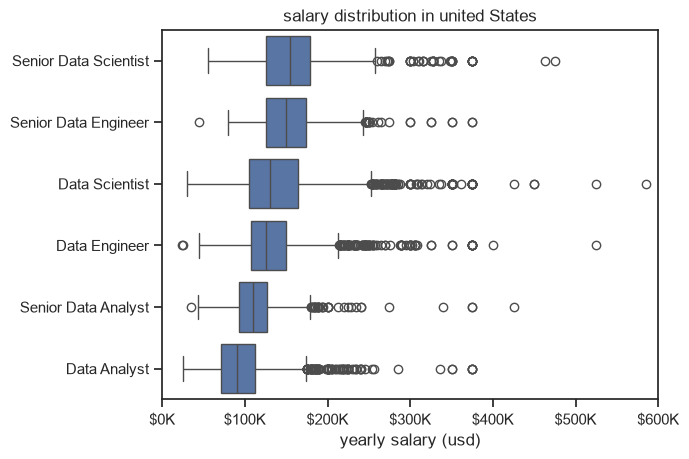

In [13]:
sns.boxplot(data=df_US_top6,x='salary_year_avg',y='job_title_short',order=job_order)
sns.set_theme(style='ticks')
# this is all the same
plt.title("salary distribution in united States")
plt.xlabel('yearly salary (usd)')
plt.ylabel('')
plt.xlim(0,600000)
ticks_x=plt.FuncFormatter(lambda y,pos:f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

# Investigate Median Salary VS skill for Data Analysis

In [14]:
df_DA_US = df[
    (df['job_title_short'] == 'Data Analyst') &
    (df['job_country'] == 'United States')
].copy()

df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

In [15]:
df_DA_US=df_DA_US.explode('job_skills')

In [18]:
df_DA_top_pay=df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])

In [19]:
df_DA_top_pay=df_DA_top_pay.head(10)



In [21]:
df_DA_skills=df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count',ascending=False)
df_DA_skills

,count,median
job_skills,,
sql,2508,91000.0
excel,1808,84392.0
python,1431,97500.0
tableau,1364,92875.0
sas,926,90000.0
...,...,...
theano,1,100000.0
typescript,1,65000.0
vmware,1,147500.0


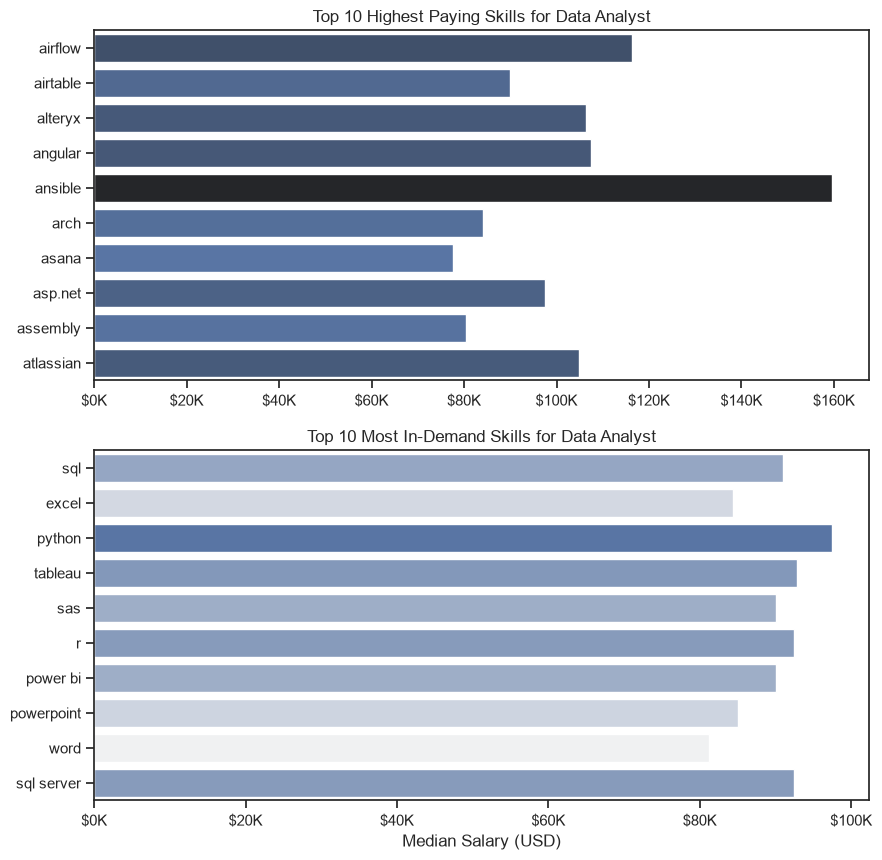

In [24]:
fig, ax = plt.subplots(2, 1, figsize=(10, 10))

sns.set_theme(style='ticks')

# Top 10 highest paying skills
sns.barplot(
    data=df_DA_top_pay,
    x='median',
    y=df_DA_top_pay.index,
    hue='median',
    palette='dark:b_r',
    legend=False,
    ax=ax[0]
)

ax[0].set_title('Top 10 Highest Paying Skills for Data Analyst')
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K')
)


# Top 10 most in-demand skills
sns.barplot(
    data=df_DA_skills.head(10),
    x='median',
    y=df_DA_skills.head(10).index,
    hue='median',
    palette='light:b',
    legend=False,
    ax=ax[1]
)

ax[1].set_title('Top 10 Most In-Demand Skills for Data Analyst')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_ylabel('')

ax[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K')
)